# E-Commerce Product Analytics
### SQL-based Funnel, Pre-purchase, and Cohort Retention Analysis

### Table of Contents
1. Project Overview
2. Data Preparation
3. Funnel Analysis
4. Pre-purchase Behavior Analysis
5. Weekly Cohort Retention
5. Business Implications
6. Export SQL Files

## 1. Project Overview

This project analyzes user behavior in an e-commerce platform using event log data.

The analysis focuses on:
- Funnel conversion (view → cart → purchase)
- Pre-purchase behavior patterns
- Weekly cohort retention

The goal is to identify key drop-off points and understand user behavior leading to conversion.  
  
---  
  
본 프로젝트는 이커머스 플랫폼의 사용자 행동 데이터를 기반으로 주요 전환 구조와 행동 패턴을 분석하는 것을 목표로 한다.

주요 분석 내용:
- 퍼널 전환 분석 (view → cart → purchase)
- 구매 직전 행동 분석
- 주차 기준 코호트 리텐션 분석

이를 통해 사용자 이탈 구간과 전환 패턴을 파악한다.

In [ ]:
!pip install duckdb -q

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb
import os

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Data Preparation

The dataset consists of user event logs including view, cart, and purchase actions.

Due to the large size of the raw data, a sampled dataset was created using chunk-based random sampling.

Key preprocessing steps:
- filtering relevant event types
- handling timestamps
- preparing data for SQL-based analysis  


### Data Source

- Kaggle: E-commerce Behavior Data  
- https://www.kaggle.com/datasets/mkechinov/ecommerce-behavior-data-from-multi-category-store

This analysis uses a sampled subset of the dataset due to its large size.

---  
  
본 데이터는 사용자 이벤트 로그(view, cart, purchase)를 포함한다.

원본 데이터가 매우 크기 때문에 chunk 기반 랜덤 샘플링을 통해 분석용 데이터를 생성하였다.

주요 전처리:
- 이벤트 유형 필터링
- 시간 데이터 처리
- SQL 분석을 위한 데이터 구조 정리

In [ ]:
file_path = "/content/drive/MyDrive/kaggle_data/2019-Nov.csv"
sample_path = "/content/drive/MyDrive/kaggle_data/2019-Nov-sample.csv"

In [ ]:
# 1) 일부만 추출하여 분석에 사용
chunks = pd.read_csv(file_path, chunksize=500000)

df_list = []

for chunk in chunks:
    sample_size = min(len(chunk), 10000)
    df_list.append(chunk.sample(sample_size, random_state=42))

df = pd.concat(df_list, ignore_index=True)

print(df.shape)

(1351979, 9)


In [ ]:
df.columns

Index(['event_time', 'event_type', 'product_id', 'category_id',
       'category_code', 'brand', 'price', 'user_id', 'user_session'],
      dtype='object')

In [ ]:
df.shape
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1351979 entries, 0 to 1351978
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype  
---  ------         --------------    -----  
 0   event_time     1351979 non-null  object 
 1   event_type     1351979 non-null  object 
 2   product_id     1351979 non-null  int64  
 3   category_id    1351979 non-null  int64  
 4   category_code  912939 non-null   object 
 5   brand          1167673 non-null  object 
 6   price          1351979 non-null  float64
 7   user_id        1351979 non-null  int64  
 8   user_session   1351978 non-null  object 
dtypes: float64(1), int64(3), object(5)
memory usage: 92.8+ MB


,0
event_time,0
event_type,0
product_id,0
category_id,0
category_code,439040
brand,184306
price,0
user_id,0
user_session,1


In [ ]:
# 2) 사용할 컬럼만 남기고 삭제
use_cols = [
    "event_time",
    "event_type",
    "product_id",
    "category_code",
    "price",
    "user_id",
    "user_session"
]

df = df[use_cols].copy()
df.head()

,event_time,event_type,product_id,category_code,price,user_id,user_session
0,2019-11-01 03:57:20 UTC,view,3700800,appliances.environment.vacuum,128.68,561394540,0d82ce6c-c81f-475d-a977-723d39e84585
1,2019-11-01 05:27:02 UTC,view,1003306,electronics.smartphone,577.89,544828613,e12cc5db-8914-4c34-a52a-c5d70691cb1f
2,2019-11-01 04:33:55 UTC,view,1307356,computers.notebook,360.11,557773679,1c0123bb-c0ad-4267-9b4b-f8a1e0efc7d6
3,2019-11-01 04:26:38 UTC,view,1004159,electronics.smartphone,1253.09,536305001,0f0255ed-527d-4f68-b821-70a7d2939c9f
4,2019-11-01 08:08:45 UTC,view,1005160,electronics.smartphone,212.08,540186874,5e40c1c7-ef4f-4b03-b5d9-100425eae5fe


In [ ]:
# 3) 날짜 형변환
df["event_time"] = pd.to_datetime(df["event_time"])
df.head()

,event_time,event_type,product_id,category_code,price,user_id,user_session
0,2019-11-01 03:57:20+00:00,view,3700800,appliances.environment.vacuum,128.68,561394540,0d82ce6c-c81f-475d-a977-723d39e84585
1,2019-11-01 05:27:02+00:00,view,1003306,electronics.smartphone,577.89,544828613,e12cc5db-8914-4c34-a52a-c5d70691cb1f
2,2019-11-01 04:33:55+00:00,view,1307356,computers.notebook,360.11,557773679,1c0123bb-c0ad-4267-9b4b-f8a1e0efc7d6
3,2019-11-01 04:26:38+00:00,view,1004159,electronics.smartphone,1253.09,536305001,0f0255ed-527d-4f68-b821-70a7d2939c9f
4,2019-11-01 08:08:45+00:00,view,1005160,electronics.smartphone,212.08,540186874,5e40c1c7-ef4f-4b03-b5d9-100425eae5fe


In [ ]:

# 4) 기본 확인
print(df.head())
print(df.info())
print(df.isnull().sum())
print(df["event_type"].value_counts())


                 event_time event_type  product_id  \
0 2019-11-01 03:57:20+00:00       view     3700800   
1 2019-11-01 05:27:02+00:00       view     1003306   
2 2019-11-01 04:33:55+00:00       view     1307356   
3 2019-11-01 04:26:38+00:00       view     1004159   
4 2019-11-01 08:08:45+00:00       view     1005160   

                   category_code    price    user_id  \
0  appliances.environment.vacuum   128.68  561394540   
1         electronics.smartphone   577.89  544828613   
2             computers.notebook   360.11  557773679   
3         electronics.smartphone  1253.09  536305001   
4         electronics.smartphone   212.08  540186874   

                           user_session  
0  0d82ce6c-c81f-475d-a977-723d39e84585  
1  e12cc5db-8914-4c34-a52a-c5d70691cb1f  
2  1c0123bb-c0ad-4267-9b4b-f8a1e0efc7d6  
3  0f0255ed-527d-4f68-b821-70a7d2939c9f  
4  5e40c1c7-ef4f-4b03-b5d9-100425eae5fe  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1351979 entries, 0 to 1351978
Data c

In [ ]:
# 5) 샘플 저장
df.to_csv(sample_path, index=False)
print("saved:", sample_path)

saved: /content/drive/MyDrive/kaggle_data/2019-Nov-sample.csv


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/kaggle_data/2019-Nov-sample.csv")
df["event_time"] = pd.to_datetime(df["event_time"])

In [ ]:
df["event_time"].min(), df["event_time"].max()

(Timestamp('2019-11-01 00:00:01+0000', tz='UTC'),
 Timestamp('2019-11-30 23:59:59+0000', tz='UTC'))

## 3. Funnel Analysis
  
##### What is Funnel Analysis?

Funnel analysis measures how users progress through a sequence of stages (e.g., view → cart → purchase) and identifies where users drop off.

It is used to:
- quantify conversion rates between stages
- identify bottlenecks in the user journey
- understand where user intent fails to translate into action  
  
---  
  
##### 퍼널 분석이란?

퍼널 분석은 사용자가 특정 단계(view → cart → purchase)를 거치면서 얼마나 다음 단계로 전환되는지를 측정하고, 어느 구간에서 이탈이 발생하는지를 파악하는 분석이다.

이를 통해:
- 단계별 전환율을 정량적으로 측정하고
- 사용자 이탈이 발생하는 병목 구간을 식별하며
- 사용자 의도가 실제 행동으로 이어지지 않는 지점을 이해할 수 있다
    

In [ ]:
funnel_sql = """
WITH base AS (
    SELECT
        event_type,
        COUNT(DISTINCT user_id) AS unique_users
    FROM df
    WHERE event_type IN ('view', 'cart', 'purchase')
    GROUP BY event_type
),
ordered AS (
    SELECT
        event_type,
        unique_users,
        CASE
            WHEN event_type = 'view' THEN 1
            WHEN event_type = 'cart' THEN 2
            WHEN event_type = 'purchase' THEN 3
        END AS stage_order
    FROM base
)
SELECT
    event_type,
    unique_users,
    ROUND(
        unique_users * 100.0 /
        MAX(CASE WHEN event_type = 'view' THEN unique_users END) OVER (),
    2) AS overall_conversion,
    ROUND(
        unique_users * 100.0 /
        LAG(unique_users) OVER (ORDER BY stage_order),
    2) AS step_conversion_rate
FROM ordered
ORDER BY stage_order;
"""

funnel_result = duckdb.sql(funnel_sql).df()
funnel_result["step_conversion_rate"] = funnel_result["step_conversion_rate"].fillna("-")
funnel_result

,event_type,unique_users,overall_conversion,step_conversion_rate
0,view,738590,100.00,-
1,cart,55346,7.49,7.49
2,purchase,17267,2.34,31.2


In [ ]:
view_users = funnel_result.loc[funnel_result["event_type"]=="view", "unique_users"].iloc[0]
cart_users = funnel_result.loc[funnel_result["event_type"]=="cart", "unique_users"].iloc[0]
purchase_users = funnel_result.loc[funnel_result["event_type"]=="purchase", "unique_users"].iloc[0]

view_to_cart = round(cart_users / view_users * 100, 2)
cart_to_purchase = round(purchase_users / cart_users * 100, 2)
view_to_purchase = round(purchase_users / view_users * 100, 2)

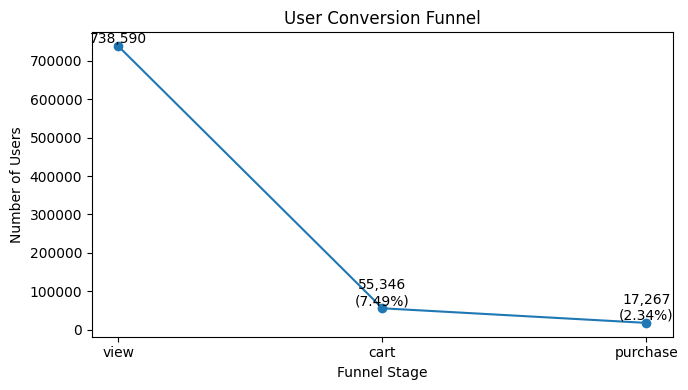

In [ ]:
funnel_df = funnel_result.copy()
order = ["view", "cart", "purchase"]
funnel_df["event_type"] = pd.Categorical(funnel_df["event_type"], categories=order, ordered=True)
funnel_df = funnel_df.sort_values("event_type")

labels = [
    f"view\n{view_users:,}",
    f"cart\n{cart_users:,}\n({view_to_cart}%)",
    f"purchase\n{purchase_users:,}\n({view_to_purchase}%)"
]

plt.figure(figsize=(7,4))
plt.plot(funnel_df["event_type"], funnel_df["unique_users"], marker="o")
plt.title("User Conversion Funnel")
plt.xlabel("Funnel Stage")
plt.ylabel("Number of Users")

for i, v in enumerate(funnel_df["unique_users"]):
    if i == 0:
        text = f"{v:,}"
    elif i == 1:
        text = f"{v:,}\n({view_to_cart}%)"
    else:
        text = f"{v:,}\n({view_to_purchase}%)"
    plt.text(i, v, text, ha="center", va="bottom")

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/kaggle_data/outputs/funnel_chart.png", dpi=150)
plt.show()



**Insight**  
  
Only 7.49% of users who viewed a product proceeded to the cart stage, while only 2.34% completed purchase from the initial view stage. This suggests friction in the exploration stage where browsing does not effectively translate into purchase intent.
  
---  
  
상품 조회 사용자 중 7.49%만 장바구니 단계로 전환되었고, 최종 구매까지 도달한 비율은 **2.34%** 에 그쳤다. 이는 구매 의도를 형성한 사용자들은 높은 확률로 구매까지 이어지지만, 사용자가 상품을 탐색하는 단계에서 구매 의도로 충분히 이어지지 않는 구조적 마찰이 존재함을 시사한다.




## 4. Pre-purchase Behavior Analysis


##### What is Pre-purchase Behavior Analysis?

Pre-purchase behavior analysis examines the actions users take immediately before completing a purchase.

It is used to:
- identify key actions that signal strong purchase intent
- understand typical paths leading to conversion
- uncover behavioral patterns among converting users    
  
---  

##### 구매 직전 행동 분석이란?

구매 직전 행동 분석은 사용자가 구매를 완료하기 직전에 어떤 행동을 했는지를 분석하는 것이다.

이를 통해:
- 구매로 이어지는 핵심 행동 신호를 파악하고
- 전환으로 이어지는 주요 행동 흐름을 이해하며
- 실제 구매 사용자들의 행동 패턴을 분석할 수 있다  


In [ ]:
pre_purchase_sql = """
WITH purchase_events AS (
    SELECT
        user_id,
        user_session,
        event_time AS purchase_time
    FROM df
    WHERE event_type = 'purchase'
),
previous_events AS (
    SELECT
        p.user_id,
        p.user_session,
        p.purchase_time,
        d.event_type,
        d.event_time,
        ROW_NUMBER() OVER (
            PARTITION BY p.user_id, p.user_session, p.purchase_time
            ORDER BY d.event_time DESC
        ) AS rn
    FROM purchase_events p
    JOIN df d
      ON p.user_id = d.user_id
     AND p.user_session = d.user_session
     AND d.event_time < p.purchase_time
),
agg AS (
    SELECT
        event_type AS previous_event,
        COUNT(*) AS transition_count
    FROM previous_events
    WHERE rn = 1
    GROUP BY 1
)
SELECT
    previous_event,
    transition_count,
    ROUND(
        transition_count * 100.0 / SUM(transition_count) OVER (),
    2) AS ratio
FROM agg
ORDER BY transition_count DESC
"""

pre_purchase_result = duckdb.sql(pre_purchase_sql).df()
pre_purchase_result

,previous_event,transition_count,ratio
0,view,1591,71.38
1,cart,564,25.30
2,purchase,74,3.32


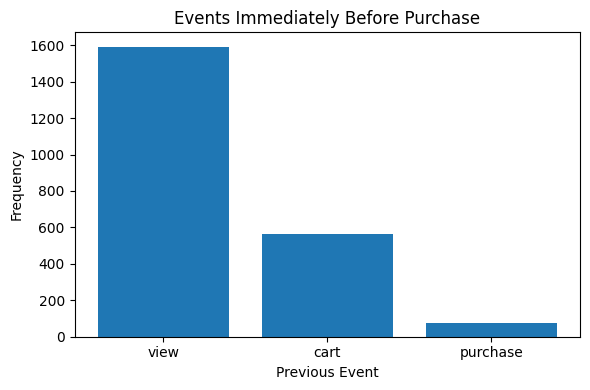

In [ ]:
plt.figure(figsize=(6,4))
plt.bar(pre_purchase_result["previous_event"], pre_purchase_result["transition_count"])
plt.title("Events Immediately Before Purchase")
plt.xlabel("Previous Event")
plt.ylabel("Frequency")

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/kaggle_data/outputs/pre_purchase_chart.png", dpi=150)
plt.show()


**Insight**  
  
Most purchases were preceded by 'view' events (71.3%), followed by 'cart' (25.3%). This suggests that many users complete purchases within a short interaction flow without extensive navigation, or that repeated product views often occur immediately before purchase. While cart remains an important signal of purchase intent, the high proportion of view → purchase transitions indicates potential opportunities to optimize the conversion experience directly from product pages.  
  
---  
  
구매 직전 행동의 약 71.3%는 'view(상품 조회)'였으며, 'cart(장바구니)'는 25.3%를 차지했다. 이는 많은 사용자가 장바구니를 거치지 않고 비교적 짧은 탐색 흐름 내에서 바로 구매를 완료하거나, 반복적인 상품 조회 이후 구매로 이어지는 패턴이 존재함을 시사한다. 장바구니 역시 중요한 구매 의도 신호이지만, 상품 상세 페이지(view)에서 바로 구매로 이어지는 비율이 높다는 점에서 상품 페이지 내 전환 최적화 여지가 존재한다.


## 5. Cohort Retention Analysis
##### What is Cohort Retention Analysis?

Cohort retention analysis tracks groups of users based on their first interaction time and measures how long they continue to engage over time.

It is used to:
- measure user retention over time  
- compare engagement across different cohorts  
- evaluate long-term user value and stickiness  

Weekly cohorts are used due to the limited time range of the dataset.  
The goal is to understand how long users remain active after their first interaction.  
  
---  
  
##### 코호트 리텐션 분석이란?

코호트 리텐션 분석은 특정 시점에 유입된 사용자 집단(cohort)을 기준으로 시간이 지남에 따라 얼마나 지속적으로 서비스를 이용하는지를 측정하는 분석이다.

이를 통해:
- 시간에 따른 사용자 유지율을 측정하고  
- 코호트 간 행동 차이를 비교하며  
- 서비스의 장기적인 사용자 유지력과 충성도를 평가할 수 있다.  

이 분석에서는 주차 기준 코호트 분석을 통해 사용자 유지율을 측정한다.  
데이터 기간이 제한되어 있어 월 단위 대신 주 단위 코호트를 사용하였다.  
이를 통해 최초 유입 이후 사용자 유지 패턴을 파악한다.



In [ ]:
weekly_cohort_sql = """
WITH base AS (
    SELECT
        user_id,
        DATE_TRUNC('week', event_time) AS event_week
    FROM df
),
first_week AS (
    SELECT
        user_id,
        MIN(event_week) AS cohort_week
    FROM base
    GROUP BY user_id
),
cohort_activity AS (
    SELECT
        b.user_id,
        f.cohort_week,
        b.event_week,
        DATE_DIFF('week', f.cohort_week, b.event_week) AS week_number
    FROM base b
    JOIN first_week f
      ON b.user_id = f.user_id
),
cohort_counts AS (
    SELECT
        cohort_week,
        week_number,
        COUNT(DISTINCT user_id) AS active_users
    FROM cohort_activity
    GROUP BY 1, 2
),
cohort_size AS (
    SELECT
        cohort_week,
        COUNT(DISTINCT user_id) AS cohort_users
    FROM first_week
    GROUP BY 1
)
SELECT
    c.cohort_week,
    c.week_number,
    c.active_users,
    s.cohort_users,
    ROUND(100.0 * c.active_users / s.cohort_users, 2) AS retention_rate
FROM cohort_counts c
JOIN cohort_size s
  ON c.cohort_week = s.cohort_week
ORDER BY c.cohort_week, c.week_number
"""


# 주 시작이 월요일 기준, DATE_TRUNC('week', event_time)

weekly_cohort_result = duckdb.sql(weekly_cohort_sql).df()
weekly_cohort_result.head(20)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,cohort_week,week_number,active_users,cohort_users,retention_rate
0,2019-10-28 00:00:00+00:00,0,73268,73268,100.00
1,2019-10-28 00:00:00+00:00,1,12634,73268,17.24
2,2019-10-28 00:00:00+00:00,2,16575,73268,22.62
3,2019-10-28 00:00:00+00:00,3,7418,73268,10.12
4,2019-10-28 00:00:00+00:00,4,6188,73268,8.45
5,2019-11-04 00:00:00+00:00,0,178235,178235,100.00
6,2019-11-04 00:00:00+00:00,1,38215,178235,21.44
7,2019-11-04 00:00:00+00:00,2,15589,178235,8.75
8,2019-11-04 00:00:00+00:00,3,12819,178235,7.19
9,2019-11-11 00:00:00+00:00,0,285572,285572,100.00


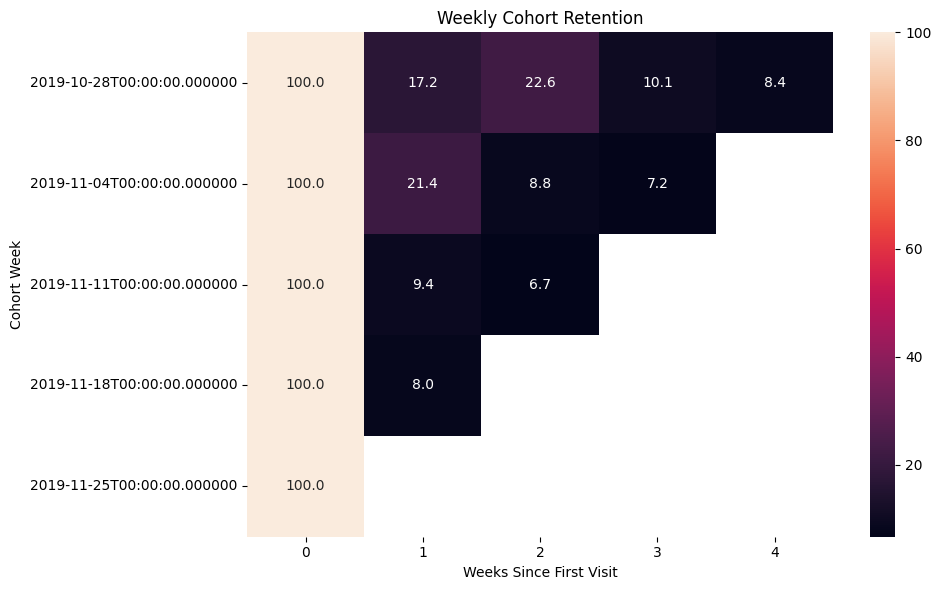

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cohort_pivot = weekly_cohort_result.pivot(
    index="cohort_week",
    columns="week_number",
    values="retention_rate"
)

plt.figure(figsize=(10,6))
sns.heatmap(cohort_pivot, annot=True, fmt=".1f")

plt.title("Weekly Cohort Retention")
plt.ylabel("Cohort Week")
plt.xlabel("Weeks Since First Visit")

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/kaggle_data/outputs/weekly_cohort_chart.png", dpi=150)
plt.show()

**Insight**  
   
This suggests that the primary issue lies in early-stage user experience, such as onboarding or initial product engagement.  

Retention drops sharply after week 1 across all cohorts, with most cohorts falling below 20%.  

Some cohorts decline to below 10% as early as week 1, indicating rapid user churn immediately after initial engagement.  

The primary issue lies in **early-stage retention (Week 0 → Week 1)** rather than long-term engagement.
  
  
---  
모든 코호트에서 1주차 이후 리텐션이 급격히 감소하며, 대부분 20% 이하 수준을 보인다.  
이는 초기 온보딩 경험이나 첫 사용 경험에서 사용자 유지에 실패하고 있을 가능성을 시사한다.  
특히 일부 코호트는 1주차에 10% 미만으로 떨어져, 초기 유입 이후 빠른 이탈이 발생하고 있음을 확인할 수 있다.  

즉, 문제는 장기 리텐션이 아니라 **초기 유지(Week 0 → Week 1)** 구간에 존재한다.  


## 6. Business Implications

The analysis identifies key drop-off points and user behavior patterns across the funnel and retention stages.

- Significant drop between view and cart  
- Product views strongly influence purchase decisions  
- Low retention after initial engagement  

These findings indicate that early-stage user experience plays a critical role in both conversion and retention.


### Action Plan

- **A/B Test Recommendation**  
  Test different product page layouts and CTA placements to improve view → cart conversion.

- **KPI Definition**  
  Track key metrics such as view-to-cart conversion rate and first-week retention rate.

- **Expected Impact**  
  Improving early-stage conversion and retention can increase overall purchase conversion and user lifetime value (LTV).

---

분석 결과는 퍼널 및 리텐션 전반에서 주요 이탈 구간과 사용자 행동 패턴을 보여준다.

- view → cart 구간에서 큰 이탈 발생  
- 상품 조회가 구매에 중요한 영향  
- 초기 이후 리텐션 낮음  

이는 초기 사용자 경험이 전환과 유지에 핵심적인 영향을 미친다는 점을 시사한다.


### 실행 전략

- **A/B 테스트 제안**  
  상품 상세 페이지의 CTA 위치 및 UI 변경을 실험하여 view → cart 전환율 개선 검증

- **핵심 KPI 정의**  
  view-to-cart 전환율, 1주차 리텐션을 주요 지표로 설정

- **예상 효과**  
  초기 전환 및 리텐션 개선 시 전체 구매 전환율 및 LTV 상승 기대

## 7. Export SQL Files

All analysis queries are exported as separate SQL files for reuse and portability.

This ensures that the analysis logic can be applied independently of the notebook environment.  
  
---
  
모든 분석 쿼리는 별도의 SQL 파일로 저장하였다.

이를 통해 노트북 환경과 분리된 상태에서도 동일한 분석을 재현할 수 있다.

In [ ]:
import zipfile

with zipfile.ZipFile("sql_files.zip", "w") as z:
    z.write("funnel_analysis.sql")
    z.write("pre_purchase_analysis.sql")
    z.write("cohort_retention.sql")

from google.colab import files
files.download("sql_files.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>